<a href="https://colab.research.google.com/github/srijalgiri/Ai-ML_sem6/blob/main/2413995_Srijal_Giri_Image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Facial Expression Classification Using CNN and Transfer Learning

In [ ]:
import os, zipfile, time, random, math, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('GPU devices:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load and Extract Dataset

The assessment requires an appropriate image dataset in image format, not a preloaded TensorFlow/PyTorch dataset. This section extracts the uploaded zip file and identifies the `train`, `validation`, and `test` folders.

In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

# ZIP file stored in your Google Drive
ZIP_PATH = Path("/content/drive/MyDrive/facial expression classification.zip")

# Where to extract inside Colab
EXTRACT_DIR = Path("/content/facial_expression_dataset")

# Remove old extracted dataset if it exists
if EXTRACT_DIR.exists():
    shutil.rmtree(EXTRACT_DIR)

EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract ZIP to /content
with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Dataset extracted successfully to:", EXTRACT_DIR)

# Find dataset root containing train / validation / test folders
possible_roots = [EXTRACT_DIR] + [p for p in EXTRACT_DIR.rglob("*") if p.is_dir()]

dataset_root = None

for p in possible_roots:
    if (p / "train").exists() and (p / "validation").exists() and (p / "test").exists():
        dataset_root = p
        break

if dataset_root is None:
    raise FileNotFoundError("Could not find train, validation and test folders after extraction.")

TRAIN_DIR = dataset_root / "train"
VAL_DIR = dataset_root / "validation"
TEST_DIR = dataset_root / "test"

print("Dataset root:", dataset_root)
print("Train dir:", TRAIN_DIR)
print("Validation dir:", VAL_DIR)
print("Test dir:", TEST_DIR)

print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

Dataset extracted successfully to: /content/facial_expression_dataset
Dataset root: /content/facial_expression_dataset/facial expression classification
Train dir: /content/facial_expression_dataset/facial expression classification/train
Validation dir: /content/facial_expression_dataset/facial expression classification/validation
Test dir: /content/facial_expression_dataset/facial expression classification/test
Train exists: True
Validation exists: True
Test exists: True


## 2. Data Understanding, Analysis, Visualisation and Cleaning

Required questions covered here:
- What the dataset represents
- Total image count
- Class distribution
- Train/validation/test split
- Preprocessing methods
- Data generators and augmentation visualisation

In [ ]:
CLASSES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
print('Classes:', CLASSES)

def count_images(split_dir):
    rows = []
    for cls in CLASSES:
        cls_dir = split_dir / cls
        count = len([p for p in cls_dir.glob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png']])
        rows.append({'split': split_dir.name, 'class': cls, 'count': count})
    return rows

counts_df = pd.DataFrame(count_images(TRAIN_DIR) + count_images(VAL_DIR) + count_images(TEST_DIR))
display(counts_df)
print('Total images:', counts_df['count'].sum())
print('\nSplit totals:')
display(counts_df.groupby('split')['count'].sum().reset_index())
print('\nClass totals:')
display(counts_df.groupby('class')['count'].sum().reset_index())

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


,split,class,count
0,train,angry,3693
1,train,disgust,336
2,train,fear,3803
3,train,happy,6864
4,train,neutral,4682
5,train,sad,4638
6,train,surprise,2905
7,validation,angry,960
8,validation,disgust,111
9,validation,fear,1018


Total images: 35887

Split totals:


,split,count
0,test,1900
1,train,26921
2,validation,7066



Class totals:


,class,count
0,angry,4953
1,disgust,547
2,fear,5121
3,happy,8989
4,neutral,6198
5,sad,6077
6,surprise,4002


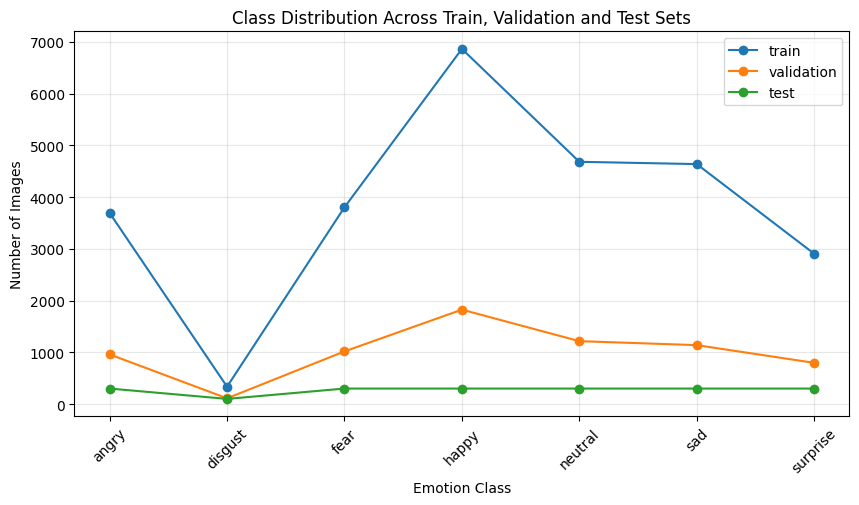

In [ ]:
plt.figure(figsize=(10,5))
for split in counts_df['split'].unique():
    sub = counts_df[counts_df['split'] == split]
    plt.plot(sub['class'], sub['count'], marker='o', label=split)
plt.title('Class Distribution Across Train, Validation and Test Sets')
plt.xlabel('Emotion Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

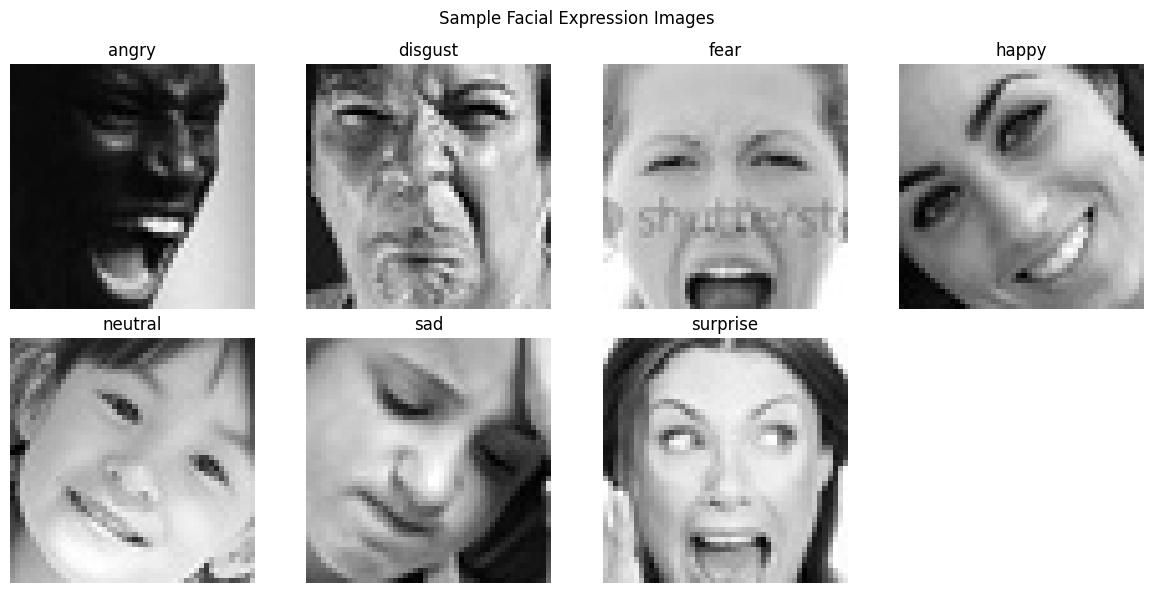

In [ ]:
# Show one sample image from each class
plt.figure(figsize=(12,6))
for i, cls in enumerate(CLASSES):
    img_path = next((TRAIN_DIR / cls).glob('*'))
    img = load_img(img_path, color_mode='grayscale')
    plt.subplot(2, 4, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls)
    plt.axis('off')
plt.suptitle('Sample Facial Expression Images')
plt.tight_layout()
plt.show()

### Preprocessing and Augmentation Choices

- Images are resized to `64 × 64` for scratch CNN models because the dataset contains low-resolution grayscale face images.
- Pixel values are normalised using `rescale=1./255`.
- Training data uses augmentation: rotation, width/height shift, zoom and horizontal flip.
- Validation and test data are only normalised, not augmented.
- Class weighting is used because the dataset is imbalanced, especially the `disgust` class.

In [ ]:
import os
from PIL import Image

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
bad_train_files = []

print("Checking train folder:", TRAIN_DIR)

for root, dirs, files in os.walk(TRAIN_DIR):
    for file in files:
        file_path = os.path.join(root, file)

        # Find hidden/system files or non-image files
        if file.startswith(".") or not file.lower().endswith(valid_extensions):
            bad_train_files.append(file_path)
            continue

        # Find corrupted image files
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            bad_train_files.append(file_path)

print("Bad files found in train folder:", len(bad_train_files))

for file in bad_train_files[:30]:
    print(file)

# Remove corrupted/non-image files from train folder only
for file in bad_train_files:
    os.remove(file)

print("Removed files from train folder:", len(bad_train_files))

Checking train folder: /content/facial_expression_dataset/facial expression classification/train
Bad files found in train folder: 49
/content/facial_expression_dataset/facial expression classification/train/surprise/20587.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/18532.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/19774.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/21366.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/33242.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/32170.jpg
/content/facial_expression_dataset/facial expression classification/train/surprise/9703.jpg
/content/facial_expression_dataset/facial expression classification/train/angry/26089.jpg
/content/facial_expression_dataset/facial expression classification/train/angry/34380.jpg
/content/facial_expression_dataset/fa

In [ ]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 64
NUM_CLASSES = len(CLASSES)
INPUT_SHAPE = (64, 64, 1)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True, seed=SEED
)
val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

idx_to_class = {v:k for k,v in train_gen.class_indices.items()}
print('Class indices:', train_gen.class_indices)

class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weights = {i: w for i, w in enumerate(class_weights_values)}
print('Class weights:', class_weights)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Class weights: {0: np.float64(1.0414696535152315), 1: np.float64(11.668258792878854), 2: np.float64(1.0112900797832305), 3: np.float64(0.559844996770766), 4: np.float64(0.8211459129106188), 5: np.float64(0.8289477743159454), 6: np.float64(1.3246573991915607)}


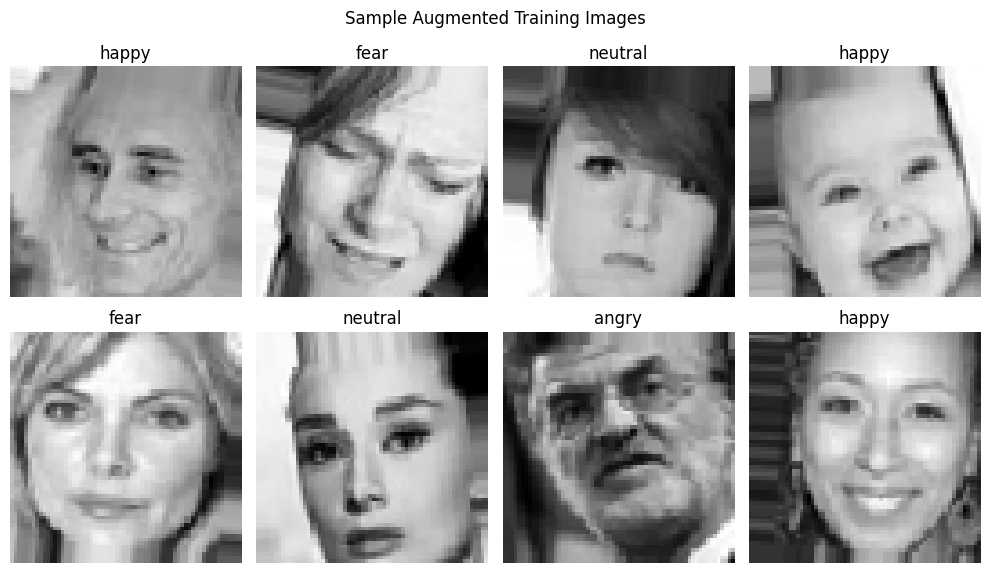

In [ ]:
# Visualise augmented images from one training batch
images, labels = next(train_gen)
plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(idx_to_class[np.argmax(labels[i])])
    plt.axis('off')
plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

# Reset generator after preview
train_gen.reset()

## 3. Helper Functions for Training, Plotting and Evaluation

In [ ]:
def get_callbacks(model_name, patience=4, monitor="val_loss", mode="min"):
    return [
        callbacks.EarlyStopping(
            monitor=monitor,
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),

        callbacks.ModelCheckpoint(
            filepath=f"{model_name}.keras",
            monitor=monitor,
            save_best_only=True,
            mode=mode,
            verbose=1
        ),

        callbacks.ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

def plot_history(history, title):
    hist = pd.DataFrame(history.history)
    plt.figure(figsize=(8,5))
    plt.plot(hist['loss'], label='Training Loss')
    plt.plot(hist['val_loss'], label='Validation Loss')
    plt.title(title + ' - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8,5))
    plt.plot(hist['accuracy'], label='Training Accuracy')
    plt.plot(hist['val_accuracy'], label='Validation Accuracy')
    plt.title(title + ' - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def evaluate_model(model, generator, model_name):
    generator.reset()
    start = time.time()
    probs = model.predict(generator, verbose=1)
    pred = np.argmax(probs, axis=1)
    true = generator.classes
    elapsed = time.time() - start

    acc = accuracy_score(true, pred)
    precision, recall, f1, _ = precision_recall_fscore_support(true, pred, average='weighted', zero_division=0)
    print(f'\n{model_name} Evaluation')
    print(f'Accuracy: {acc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1-score: {f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(true, pred, target_names=[idx_to_class[i] for i in range(NUM_CLASSES)], zero_division=0))

    cm = confusion_matrix(true, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=[idx_to_class[i] for i in range(NUM_CLASSES)])
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=45, cmap=None, colorbar=False)
    plt.title(model_name + ' Confusion Matrix')
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'prediction_time_sec': elapsed}

def show_predictions(model, generator, model_name, n=8):
    generator.reset()
    imgs, labels = next(generator)
    probs = model.predict(imgs, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels, axis=1)

    plt.figure(figsize=(12,6))
    for i in range(min(n, len(imgs))):
        plt.subplot(2, 4, i+1)
        plt.imshow(imgs[i].squeeze(), cmap='gray')
        plt.title(f'True: {idx_to_class[true[i]]}\nPred: {idx_to_class[preds[i]]}')
        plt.axis('off')
    plt.suptitle(model_name + ' Sample Predictions')
    plt.tight_layout()
    plt.show()

## 4. Part A – Baseline CNN from Scratch

Assessment requirement: baseline CNN with **three convolutional layers**, each followed by pooling, **three fully connected layers**, and an output layer suitable for multiclass classification.

In [ ]:
def build_baseline_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential(name='Baseline_CNN')
    model.add(layers.Input(shape=input_shape))

    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(optimizer=optimizers.Adam(learning_rate=5e-4), loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,231,687 (8.51 MB)

 Trainable params: 2,231,687 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.1388 - loss: 1.9575
Epoch 1: val_loss improved from None to 1.79933, saving model to baseline_cnn.keras

Epoch 1: finished saving model to baseline_cnn.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 42s 86ms/step - accuracy: 0.1812 - loss: 1.9115 - val_accuracy: 0.2900 - val_loss: 1.7993 - learning_rate: 5.0000e-04
Epoch 2/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.2583 - loss: 1.8379
Epoch 2: val_loss improved from 1.79933 to 1.77405, saving model to baseline_cnn.keras

Epoch 2: finished saving model to baseline_cnn.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.2657 - loss: 1.8107 - val_accuracy: 0.2931 - val_loss: 1.7740 - learning_rate: 5.0000e-04
Epoch 3/20
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3061 - loss: 1.7472
Epoch 3: val_loss improved from 1.77405 to 1.64322, saving model to baseline_cnn.keras

Epoch 3: finished saving model to baseline_cnn.keras
420/420 ━━━━━━━━━━━━━━━━━

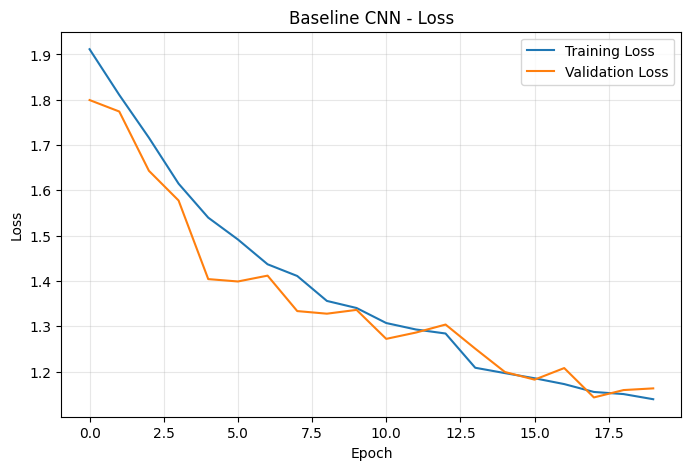

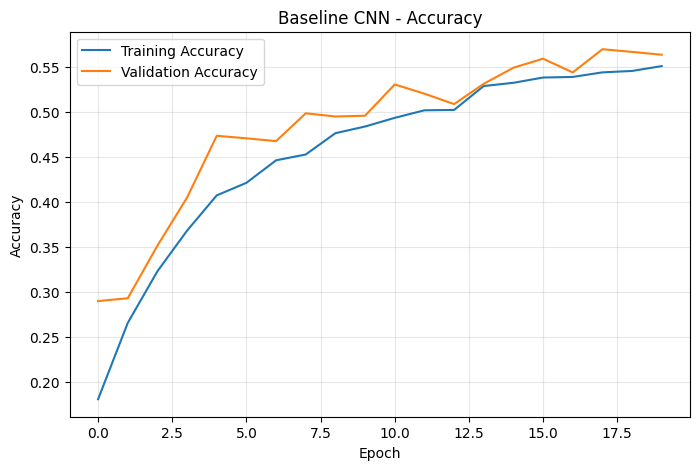

In [ ]:
BASELINE_EPOCHS = 20

start_time = time.time()
baseline_history = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=BASELINE_EPOCHS,
    callbacks=get_callbacks('baseline_cnn'),
    class_weight=class_weights,
    verbose=1
)
baseline_time = time.time() - start_time
print(f'Baseline training time: {baseline_time:.2f} seconds')

plot_history(baseline_history, 'Baseline CNN')

In [ ]:
from tensorflow.keras.models import load_model

best_baseline_cnn_model = load_model("baseline_cnn.keras")

baseline_test_loss, baseline_test_acc = best_baseline_cnn_model.evaluate(test_gen)

print("Best baseline CNN Test Accuracy:", baseline_test_acc)
print("Best baseline CNN Test Loss:", baseline_test_loss)

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5337 - loss: 1.2363
Best baseline CNN Test Accuracy: 0.5336841940879822
Best baseline CNN Test Loss: 1.236255168914795


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step

Baseline CNN Evaluation
Accuracy: 0.5337 | Precision: 0.5318 | Recall: 0.5337 | F1-score: 0.5285

Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.53      0.49       300
     disgust       0.58      0.56      0.57       100
        fear       0.41      0.26      0.32       300
       happy       0.74      0.71      0.73       300
     neutral       0.46      0.58      0.51       300
         sad       0.41      0.38      0.39       300
    surprise       0.72      0.72      0.72       300

    accuracy                           0.53      1900
   macro avg       0.54      0.54      0.53      1900
weighted avg       0.53      0.53      0.53      1900



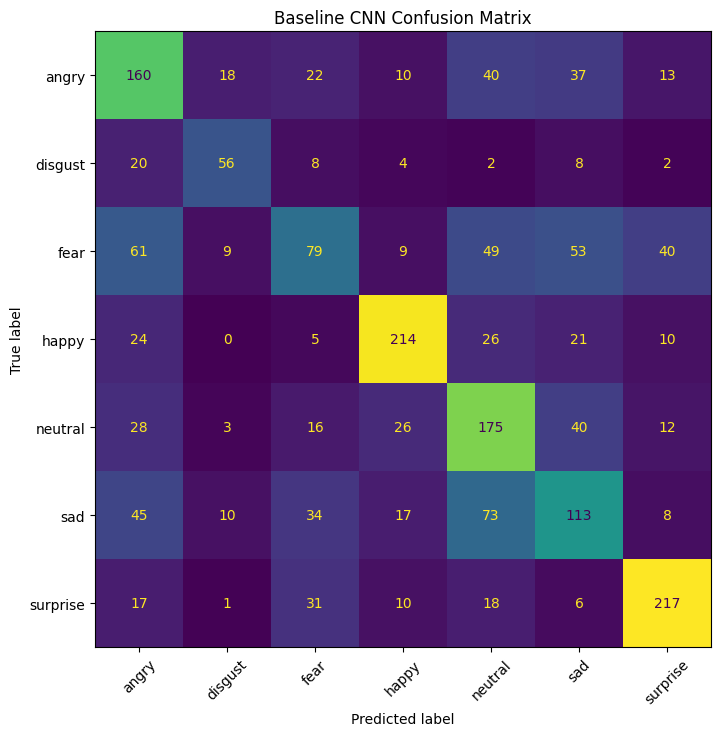

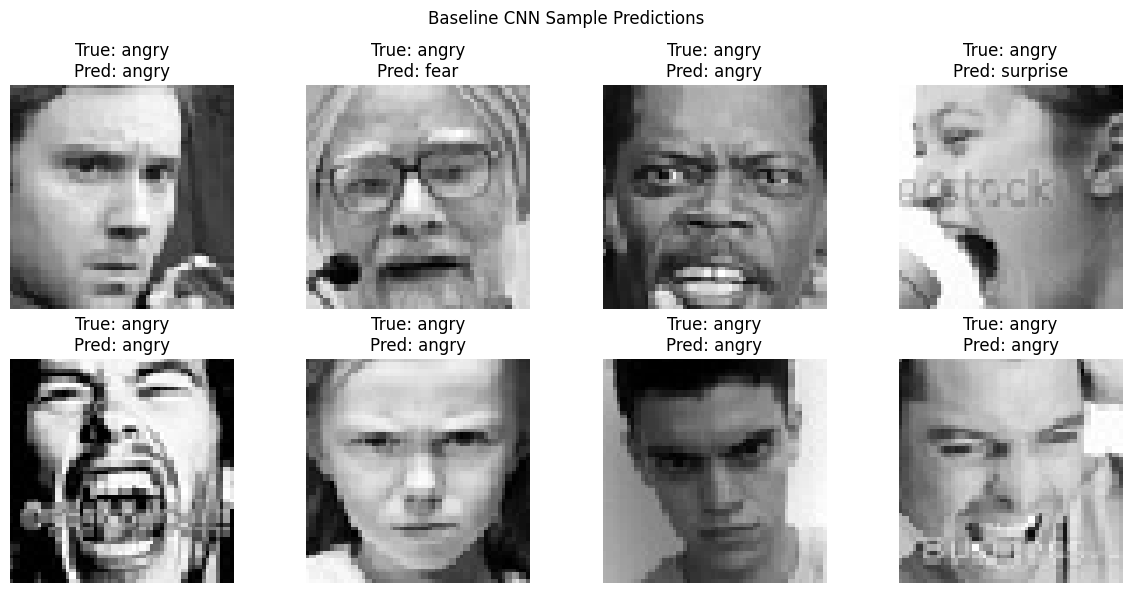

In [ ]:
results = []
results.append(evaluate_model(baseline_model, test_gen, 'Baseline CNN'))
show_predictions(baseline_model, test_gen, 'Baseline CNN')

## 5. Part A – Deeper CNN with Regularisation

Assessment requirement: deeper architecture with at least double the convolutional layers compared with the baseline. This model uses six convolutional layers, Batch Normalisation and Dropout to reduce overfitting.

In [ ]:
def build_deeper_cnn(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential(name="Deeper_CNN_With_Regularisation")

    model.add(layers.Input(shape=input_shape))

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.15))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.20))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(128, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # Extra deeper feature layer
    model.add(layers.Conv2D(256, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dropout(0.30))

    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.20))

    model.add(layers.Dense(num_classes, activation="softmax"))

    return model


deeper_adam_model = build_deeper_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES
)

deeper_adam_model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_adam_model.summary()

Model: "Deeper_CNN_With_Regularisation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 4,812,775 (18.36 MB)

 Trainable params: 4,811,367 (18.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2236 - loss: 1.8976
Epoch 1: val_loss improved from None to 1.90036, saving model to deeper_cnn_adam.keras

Epoch 1: finished saving model to deeper_cnn_adam.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.2422 - loss: 1.8274 - val_accuracy: 0.2583 - val_loss: 1.9004 - learning_rate: 3.0000e-04
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2856 - loss: 1.7397
Epoch 2: val_loss improved from 1.90036 to 1.58764, saving model to deeper_cnn_adam.keras

Epoch 2: finished saving model to deeper_cnn_adam.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.2946 - loss: 1.7188 - val_accuracy: 0.3634 - val_loss: 1.5876 - learning_rate: 3.0000e-04
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3403 - loss: 1.6329
Epoch 3: val_loss improved from 1.58764 to 1.58414, saving model to deeper_cnn_adam.keras

Epoch 3: finished saving model to deeper_cnn_adam.keras
420/42

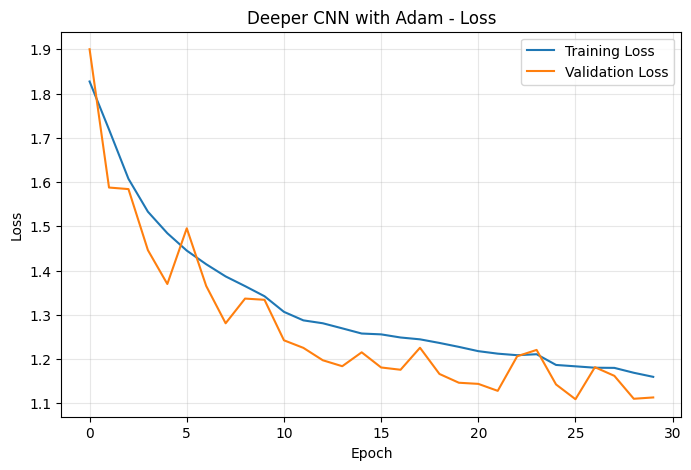

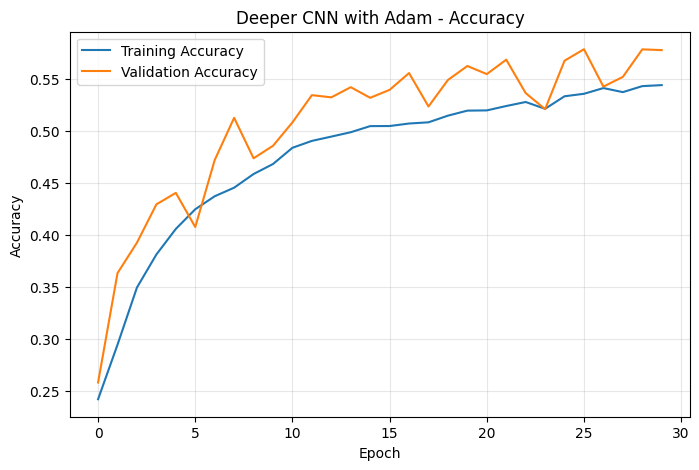

In [ ]:
DEEPER_EPOCHS = 30

start_time = time.time()

deeper_adam_history = deeper_adam_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=DEEPER_EPOCHS,
    callbacks=get_callbacks("deeper_cnn_adam", patience=6),
    verbose=1
)

deeper_adam_time = time.time() - start_time

print(f"Deeper CNN with Adam training time: {deeper_adam_time:.2f} seconds")

plot_history(deeper_adam_history, "Deeper CNN with Adam")

In [ ]:
from tensorflow.keras.models import load_model

best_deeper_adam_model = load_model("deeper_cnn_adam.keras")

deeper_test_loss, deeper_test_acc = best_deeper_adam_model.evaluate(test_gen)

print("Best Deeper CNN Test Accuracy:", deeper_test_acc)
print("Best Deeper CNN Test Loss:", deeper_test_loss)

30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 109ms/step - accuracy: 0.5158 - loss: 1.2899
Best Deeper CNN Test Accuracy: 0.5157894492149353
Best Deeper CNN Test Loss: 1.2899391651153564


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step

Deeper CNN with Adam Evaluation
Accuracy: 0.5158 | Precision: 0.4857 | Recall: 0.5158 | F1-score: 0.4901

Classification Report:
              precision    recall  f1-score   support

       angry       0.39      0.37      0.38       300
     disgust       0.00      0.00      0.00       100
        fear       0.38      0.21      0.27       300
       happy       0.72      0.85      0.78       300
     neutral       0.46      0.74      0.57       300
         sad       0.34      0.39      0.36       300
    surprise       0.78      0.71      0.74       300

    accuracy                           0.52      1900
   macro avg       0.44      0.47      0.44      1900
weighted avg       0.49      0.52      0.49      1900



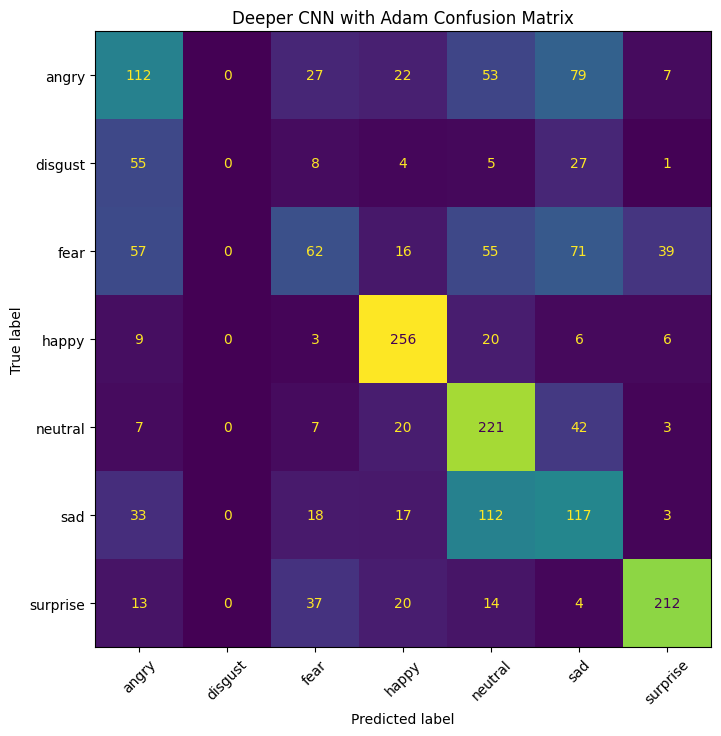

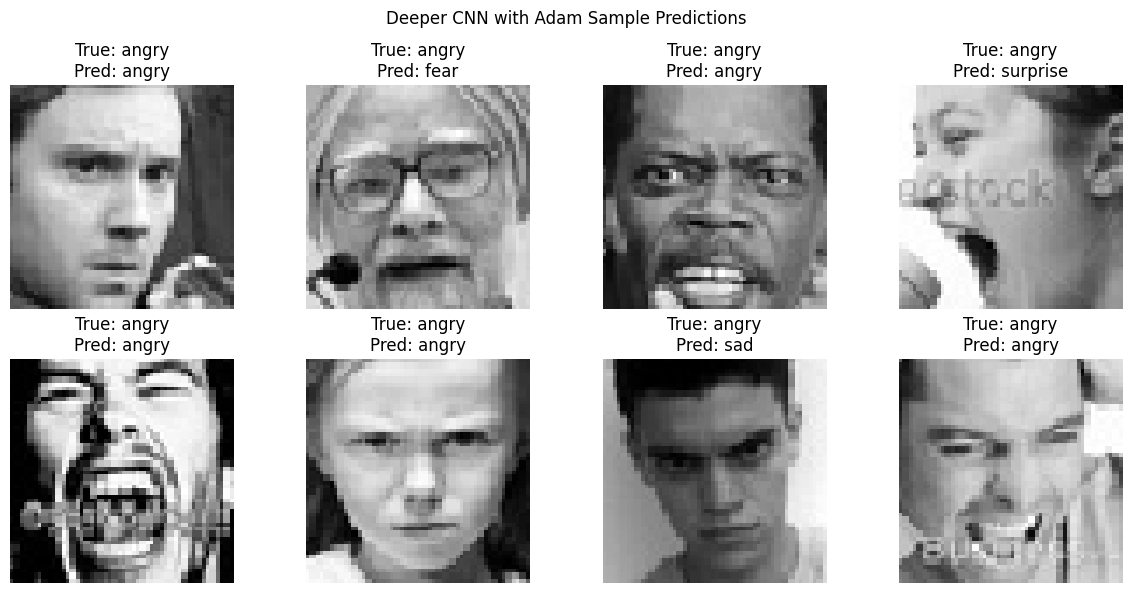

In [ ]:
results.append(evaluate_model(deeper_adam_model, test_gen, 'Deeper CNN with Adam'))
show_predictions(deeper_adam_model, test_gen, 'Deeper CNN with Adam')

## 6. Optimizer Analysis – SGD vs Adam

The same deeper architecture is trained with SGD and Adam so convergence speed and final performance can be compared.

In [ ]:
deeper_sgd_model = build_deeper_cnn(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES
)

deeper_sgd_model.compile(
    optimizer=optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9,
        nesterov=True
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

deeper_sgd_model.summary()

Model: "Deeper_CNN_With_Regularisation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 16, 16, 128)    │             

 Total params: 4,812,775 (18.36 MB)

 Trainable params: 4,811,367 (18.35 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.2238 - loss: 1.8687
Epoch 1: val_loss improved from None to 1.87846, saving model to deeper_cnn_sgd.keras

Epoch 1: finished saving model to deeper_cnn_sgd.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 50s 94ms/step - accuracy: 0.2388 - loss: 1.8277 - val_accuracy: 0.2583 - val_loss: 1.8785 - learning_rate: 0.0010
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.2616 - loss: 1.7746
Epoch 2: val_loss improved from 1.87846 to 1.66895, saving model to deeper_cnn_sgd.keras

Epoch 2: finished saving model to deeper_cnn_sgd.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 31s 75ms/step - accuracy: 0.2682 - loss: 1.7626 - val_accuracy: 0.3428 - val_loss: 1.6690 - learning_rate: 0.0010
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.2948 - loss: 1.7269
Epoch 3: val_loss improved from 1.66895 to 1.61456, saving model to deeper_cnn_sgd.keras

Epoch 3: finished saving model to deeper_cnn_sgd.keras
420/420 ━━━━━━━━━━━━━

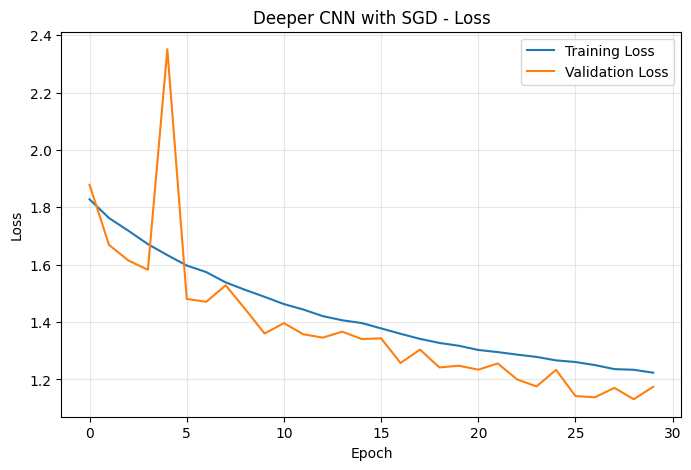

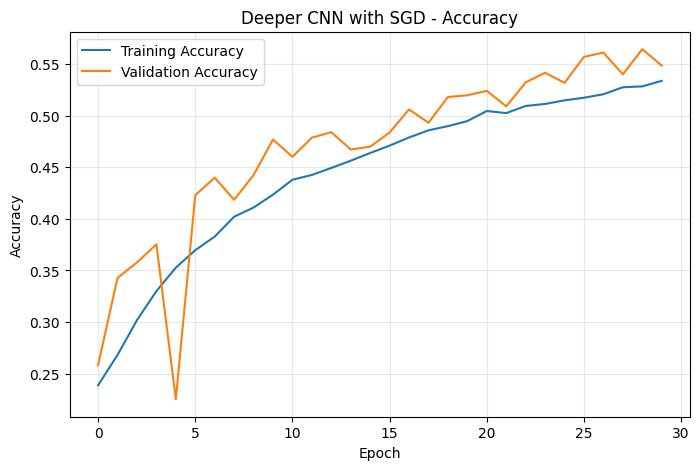

In [ ]:
DEEPER_EPOCHS = 30

start_time = time.time()

deeper_sgd_history = deeper_sgd_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=DEEPER_EPOCHS,
    callbacks=get_callbacks("deeper_cnn_sgd", patience=6),
    verbose=1
)

deeper_sgd_time = time.time() - start_time

print(f"Deeper CNN with SGD training time: {deeper_sgd_time:.2f} seconds")

plot_history(deeper_sgd_history, "Deeper CNN with SGD")

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step

Deeper CNN with SGD Evaluation
Accuracy: 0.5011 | Precision: 0.5429 | Recall: 0.5011 | F1-score: 0.4773

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.26      0.35       300
     disgust       0.93      0.13      0.23       100
        fear       0.41      0.15      0.22       300
       happy       0.65      0.83      0.73       300
     neutral       0.43      0.58      0.50       300
         sad       0.32      0.62      0.42       300
    surprise       0.77      0.69      0.73       300

    accuracy                           0.50      1900
   macro avg       0.58      0.47      0.45      1900
weighted avg       0.54      0.50      0.48      1900



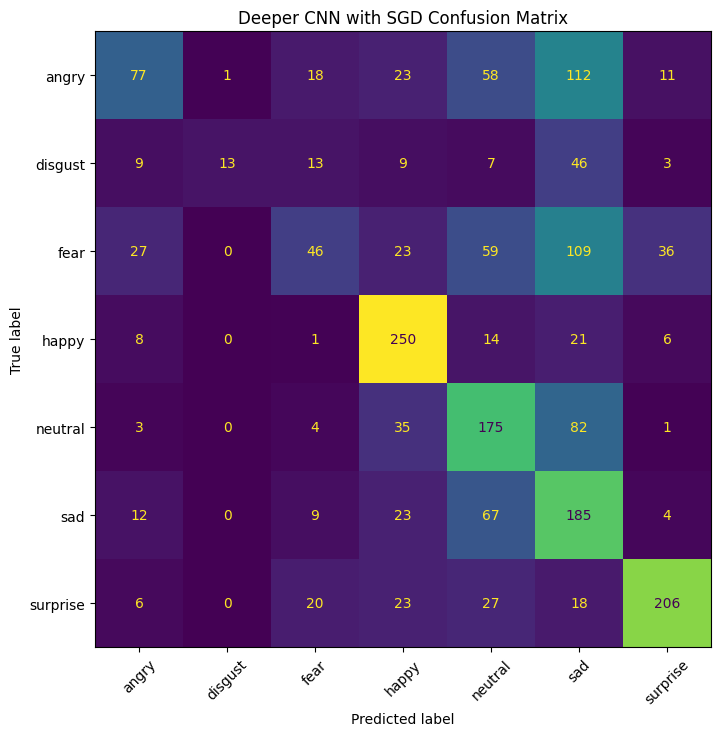

In [ ]:
from tensorflow.keras.models import load_model

best_deeper_sgd_model = load_model("deeper_cnn_sgd.keras")

results.append(
    evaluate_model(best_deeper_sgd_model, test_gen, "Deeper CNN with SGD")
)

## 7. Ablation Study – Removing Dropout

This experiment removes Dropout while keeping the deeper architecture and Batch Normalisation. The purpose is to examine whether Dropout helped control overfitting.

In [ ]:
def build_ablation_no_dropout(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = models.Sequential(name="Ablation_Deeper_CNN_No_Dropout")

    model.add(layers.Input(shape=input_shape))

    # Same deeper CNN structure, but without Dropout layers

    # Block 1
    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(32, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(64, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))

    # Block 3
    model.add(layers.Conv2D(128, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.Conv2D(128, (3, 3), padding="same", activation=None))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))

    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

In [ ]:
ablation_model = build_ablation_no_dropout(
    input_shape=INPUT_SHAPE,
    num_classes=NUM_CLASSES
)

ablation_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

ablation_model.summary()

Model: "Ablation_Deeper_CNN_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             

 Total params: 2,419,431 (9.23 MB)

 Trainable params: 2,418,535 (9.23 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.2607 - loss: 1.9750
Epoch 1: val_loss improved from None to 1.71619, saving model to deeper_cnn_no_dropout.keras

Epoch 1: finished saving model to deeper_cnn_no_dropout.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 48s 90ms/step - accuracy: 0.3058 - loss: 1.7562 - val_accuracy: 0.2942 - val_loss: 1.7162 - learning_rate: 5.0000e-04
Epoch 2/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.3998 - loss: 1.5304
Epoch 2: val_loss improved from 1.71619 to 1.48596, saving model to deeper_cnn_no_dropout.keras

Epoch 2: finished saving model to deeper_cnn_no_dropout.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.4240 - loss: 1.4798 - val_accuracy: 0.4372 - val_loss: 1.4860 - learning_rate: 5.0000e-04
Epoch 3/30
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4645 - loss: 1.3855
Epoch 3: val_loss improved from 1.48596 to 1.36450, saving model to deeper_cnn_no_dropout.keras

Epoch 3: finished saving model to

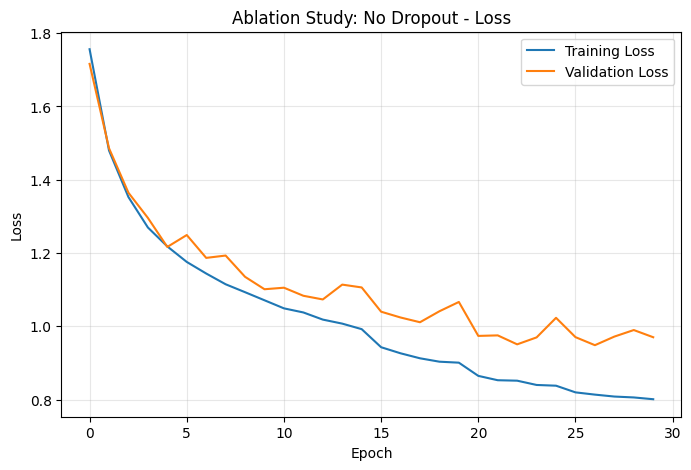

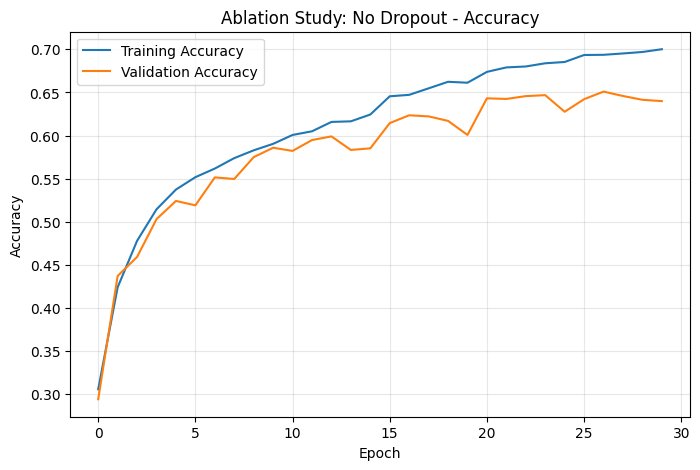

In [ ]:
start_time = time.time()

ablation_history = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=DEEPER_EPOCHS,
    callbacks=get_callbacks("deeper_cnn_no_dropout", patience=6),
    verbose=1
)

ablation_time = time.time() - start_time

print(f"Ablation model training time: {ablation_time:.2f} seconds")

plot_history(ablation_history, "Ablation Study: No Dropout")

30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 207ms/step

Deeper CNN No Dropout Evaluation
Accuracy: 0.6021 | Precision: 0.6168 | Recall: 0.6021 | F1-score: 0.5923

Classification Report:
              precision    recall  f1-score   support

       angry       0.54      0.54      0.54       300
     disgust       0.91      0.32      0.47       100
        fear       0.55      0.33      0.41       300
       happy       0.74      0.85      0.80       300
     neutral       0.48      0.76      0.59       300
         sad       0.49      0.46      0.47       300
    surprise       0.80      0.76      0.78       300

    accuracy                           0.60      1900
   macro avg       0.65      0.58      0.58      1900
weighted avg       0.62      0.60      0.59      1900



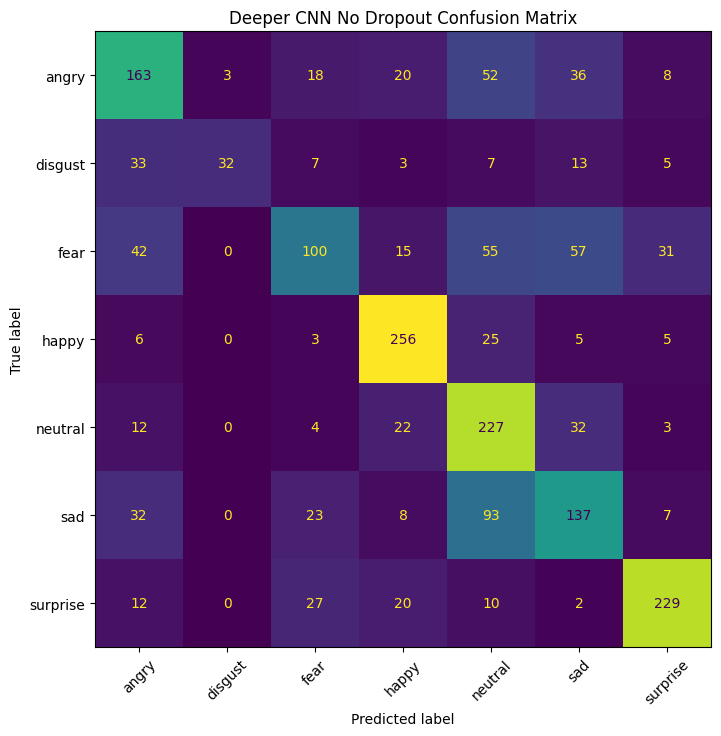

In [ ]:
results.append(
    evaluate_model(ablation_model, test_gen, "Deeper CNN No Dropout")
)

## 8. Part B – Transfer Learning with MobileNetV2

MobileNetV2 is selected because it is lightweight and suitable for Colab GPU training. Since ImageNet models expect RGB images, grayscale facial images are loaded as RGB and resized to `96 × 96` for efficient transfer learning.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

TL_IMG_SIZE = (96, 96)
TL_BATCH_SIZE = 64

transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

transfer_val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

transfer_train_gen = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=TL_BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

transfer_val_gen = transfer_val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=TL_BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

transfer_test_gen = transfer_val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=TL_IMG_SIZE,
    color_mode="rgb",
    batch_size=TL_BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Transfer train batches:", len(transfer_train_gen))
print("Transfer val batches:", len(transfer_val_gen))
print("Transfer test batches:", len(transfer_test_gen))
print("Class indices:", transfer_train_gen.class_indices)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.
Transfer train batches: 420
Transfer val batches: 111
Transfer test batches: 30
Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers

def build_transfer_model(num_classes=NUM_CLASSES):
    try:
        base = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3)
        )
        print("Loaded MobileNetV2 with ImageNet pretrained weights.")
    except Exception as e:
        print("Could not download ImageNet weights. Falling back to weights=None. Error:", e)
        base = MobileNetV2(
            weights=None,
            include_top=False,
            input_shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3)
        )

    # Stage 1: freeze pretrained convolutional base
    base.trainable = False

    inputs = layers.Input(shape=(TL_IMG_SIZE[0], TL_IMG_SIZE[1], 3))

    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(256, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.40)(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.25)(x)

    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs,
        name="MobileNetV2_Transfer_Learning"
    )

    return model, base


transfer_model, transfer_base = build_transfer_model()

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=5e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded MobileNetV2 with ImageNet pretrained weights.


Model: "MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 362,247 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.4769 - loss: 1.3721
Epoch 1: val_loss improved from None to 1.45816, saving model to mobilenetv2_transfer.keras

Epoch 1: finished saving model to mobilenetv2_transfer.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 83s 198ms/step - accuracy: 0.4756 - loss: 1.3705 - val_accuracy: 0.4374 - val_loss: 1.4582 - learning_rate: 5.0000e-04
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.4831 - loss: 1.3532
Epoch 2: val_loss improved from 1.45816 to 1.43588, saving model to mobilenetv2_transfer.keras

Epoch 2: finished saving model to mobilenetv2_transfer.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 84s 199ms/step - accuracy: 0.4809 - loss: 1.3633 - val_accuracy: 0.4382 - val_loss: 1.4359 - learning_rate: 5.0000e-04
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4847 - loss: 1.3533
Epoch 3: val_loss improved from 1.43588 to 1.43195, saving model to mobilenetv2_transfer.keras

Epoch 3: finished saving model to

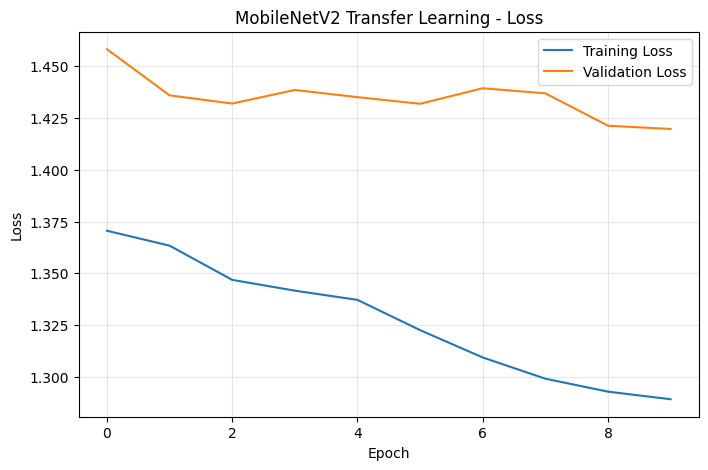

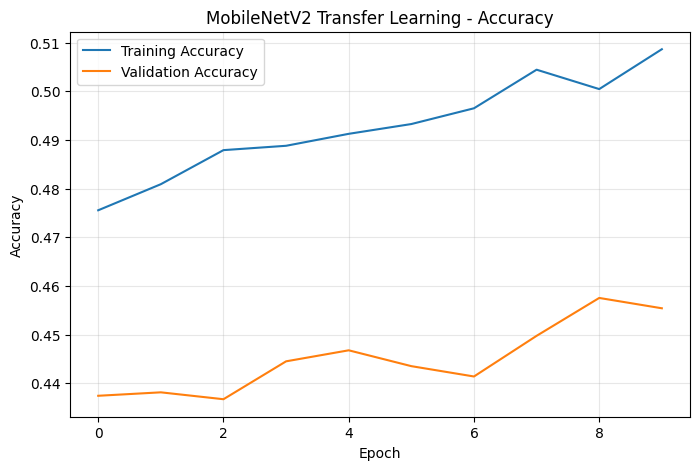

In [ ]:
TRANSFER_EPOCHS = 10

start_time = time.time()

transfer_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=TRANSFER_EPOCHS,
    callbacks=get_callbacks("mobilenetv2_transfer", patience=5),
    verbose=1
)

transfer_time = time.time() - start_time

print(f"MobileNetV2 transfer learning training time: {transfer_time:.2f} seconds")

plot_history(transfer_history, "MobileNetV2 Transfer Learning")

Loaded best frozen MobileNetV2 transfer model.
MobileNetV2 base layer found: mobilenetv2_1.00_96
Fine-tuning setup complete.
Trainable layers in MobileNetV2 base:
block_15_depthwise_relu
block_15_project
block_15_add
block_16_expand
block_16_expand_relu
block_16_depthwise
block_16_depthwise_relu
block_16_project
Conv_1
out_relu
Total trainable layers in base: 10


Model: "MobileNetV2_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,743 (10.00 MB)

 Trainable params: 1,394,887 (5.32 MB)

 Non-trainable params: 1,225,856 (4.68 MB)

Epoch 1/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5100 - loss: 1.2812
Epoch 1: val_loss improved from None to 1.41391, saving model to mobilenetv2_fine_tuned.keras

Epoch 1: finished saving model to mobilenetv2_fine_tuned.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 112s 234ms/step - accuracy: 0.5083 - loss: 1.2852 - val_accuracy: 0.4602 - val_loss: 1.4139 - learning_rate: 1.0000e-06
Epoch 2/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.5124 - loss: 1.2773
Epoch 2: val_loss did not improve from 1.41391
420/420 ━━━━━━━━━━━━━━━━━━━━ 84s 201ms/step - accuracy: 0.5097 - loss: 1.2760 - val_accuracy: 0.4563 - val_loss: 1.4142 - learning_rate: 1.0000e-06
Epoch 3/10
420/420 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step - accuracy: 0.5197 - loss: 1.2659
Epoch 3: val_loss improved from 1.41391 to 1.40665, saving model to mobilenetv2_fine_tuned.keras

Epoch 3: finished saving model to mobilenetv2_fine_tuned.keras
420/420 ━━━━━━━━━━━━━━━━━━━━ 85s 203ms/step - accuracy: 0.5150 - loss: 1.

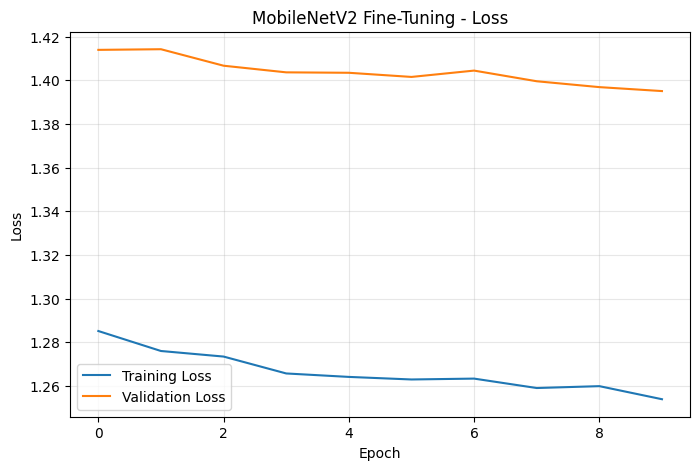

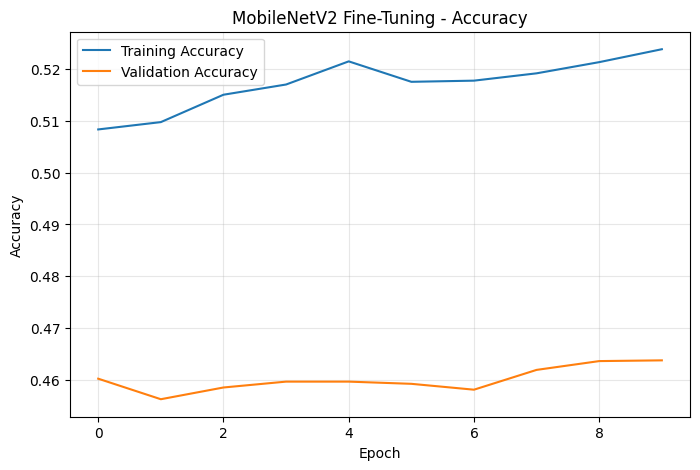

Evaluating best saved fine-tuned MobileNetV2 model...
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 430ms/step - accuracy: 0.4137 - loss: 1.5601
Best Fine-Tuned MobileNetV2 Test Accuracy: 0.413684219121933
Best Fine-Tuned MobileNetV2 Test Loss: 1.5600661039352417
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 164ms/step

Fine-Tuned MobileNetV2 Evaluation
Accuracy: 0.4137 | Precision: 0.4835 | Recall: 0.4137 | F1-score: 0.3951

Classification Report:
              precision    recall  f1-score   support

       angry       0.43      0.29      0.35       300
     disgust       1.00      0.02      0.04       100
        fear       0.38      0.17      0.24       300
       happy       0.41      0.72      0.52       300
     neutral       0.45      0.40      0.42       300
         sad       0.29      0.57      0.39       300
    surprise       0.77      0.46      0.57       300

    accuracy                           0.41      1900
   macro avg       0.53      0.38      0.36      1900
weighted avg       0.48      0.41   

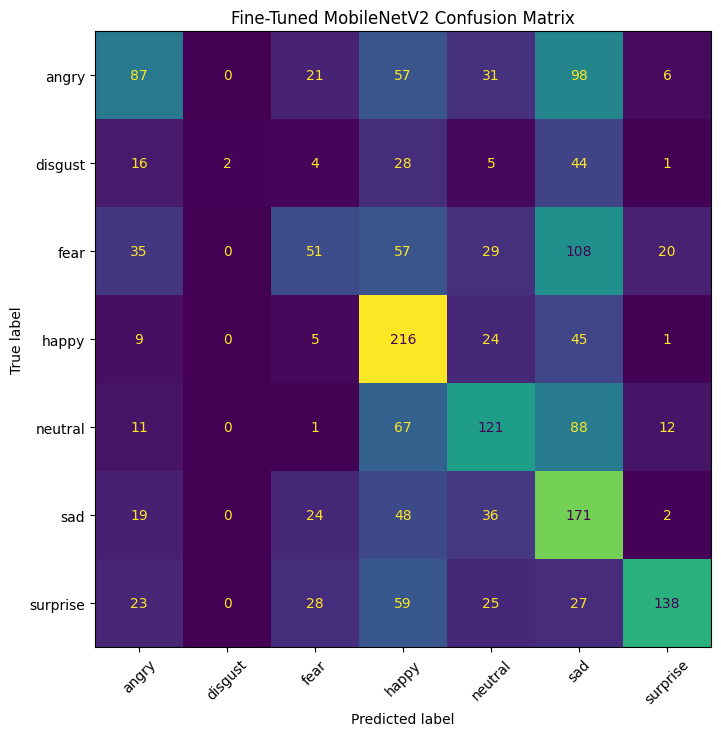

In [ ]:
# ===============================================================
# MobileNetV2 Fine-Tuning - Full Code
# ===============================================================

import time
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, optimizers

# ---------------------------------------------------------------
# 1. Load the best frozen transfer learning model
# ---------------------------------------------------------------

transfer_model = load_model("mobilenetv2_transfer.keras")

print("Loaded best frozen MobileNetV2 transfer model.")


# ---------------------------------------------------------------
# 2. Find the MobileNetV2 base layer automatically
# ---------------------------------------------------------------

transfer_base = None

for layer in transfer_model.layers:
    if "mobilenetv2" in layer.name.lower():
        transfer_base = layer
        break

if transfer_base is None:
    print("Could not automatically find MobileNetV2 base layer.")
    print("Available layers:")
    for layer in transfer_model.layers:
        print(layer.name)
    raise ValueError("MobileNetV2 base layer not found.")

print("MobileNetV2 base layer found:", transfer_base.name)


# ---------------------------------------------------------------
# 3. Unfreeze only the last 15 layers
# ---------------------------------------------------------------

transfer_base.trainable = True

# Freeze most MobileNetV2 layers
for layer in transfer_base.layers[:-15]:
    layer.trainable = False

# Keep BatchNormalization layers frozen for stable fine-tuning
for layer in transfer_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Fine-tuning setup complete.")
print("Trainable layers in MobileNetV2 base:")

trainable_count = 0
for layer in transfer_base.layers:
    if layer.trainable:
        trainable_count += 1
        print(layer.name)

print("Total trainable layers in base:", trainable_count)


# ---------------------------------------------------------------
# 4. Compile with very low learning rate
# ---------------------------------------------------------------

transfer_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-6),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

transfer_model.summary()


# ---------------------------------------------------------------
# 5. Fine-tune model
# ---------------------------------------------------------------

FINE_TUNE_EPOCHS = 10

start_time = time.time()

fine_tune_history = transfer_model.fit(
    transfer_train_gen,
    validation_data=transfer_val_gen,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=get_callbacks("mobilenetv2_fine_tuned", patience=4),
    verbose=1
)

fine_tune_time = time.time() - start_time

print(f"MobileNetV2 fine-tuning time: {fine_tune_time:.2f} seconds")


# ---------------------------------------------------------------
# 6. Plot fine-tuning history
# ---------------------------------------------------------------

plot_history(fine_tune_history, "MobileNetV2 Fine-Tuning")


# ---------------------------------------------------------------
# 7. Load and evaluate best saved fine-tuned model
# ---------------------------------------------------------------

best_finetuned_model = load_model("mobilenetv2_fine_tuned.keras")

print("Evaluating best saved fine-tuned MobileNetV2 model...")

fine_tune_test_loss, fine_tune_test_acc = best_finetuned_model.evaluate(transfer_test_gen)

print("Best Fine-Tuned MobileNetV2 Test Accuracy:", fine_tune_test_acc)
print("Best Fine-Tuned MobileNetV2 Test Loss:", fine_tune_test_loss)


# ---------------------------------------------------------------
# 8. Add result to results list
# ---------------------------------------------------------------

results.append(
    evaluate_model(
        best_finetuned_model,
        transfer_test_gen,
        "Fine-Tuned MobileNetV2"
    )
)

## 9. Final Comparative Analysis

This table compares accuracy, precision, recall, F1-score, prediction time, and training time. Use these results in the final report to discuss performance, computational efficiency and trade-offs.

,model,accuracy,precision,recall,f1,prediction_time_sec,training_time_sec
3,Deeper CNN No Dropout,0.602105,0.616847,0.602105,0.592327,8.438279,967.159604
0,Baseline CNN,0.533684,0.531812,0.533684,0.528482,1.874130,610.275236
1,Deeper CNN with Adam,0.515789,0.485733,0.515789,0.490071,2.284772,1002.937240
2,Deeper CNN with SGD,0.501053,0.542879,0.501053,0.477261,5.255976,998.435777
4,Fine-Tuned MobileNetV2,0.413684,0.483541,0.413684,0.395106,8.875250,NaN


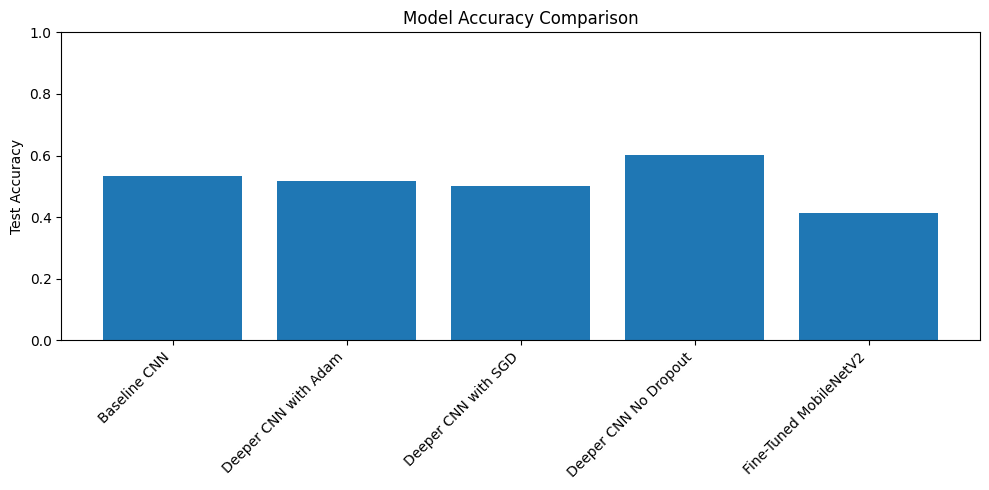

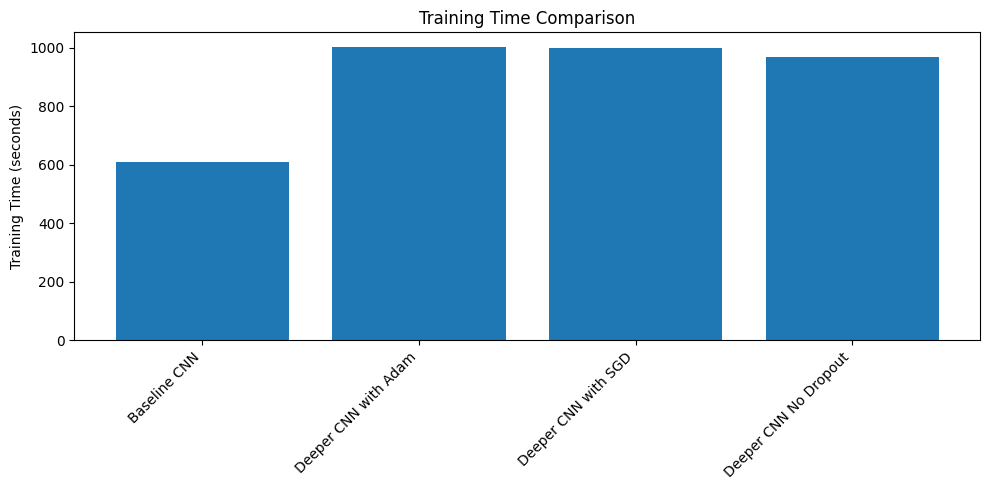

In [ ]:
training_times = {
    'Baseline CNN': baseline_time,
    'Deeper CNN with Adam': deeper_adam_time,
    'Deeper CNN with SGD': deeper_sgd_time,
    'Deeper CNN No Dropout': ablation_time,
    'MobileNetV2 Transfer Learning': transfer_time + fine_tune_time
}

results_df = pd.DataFrame(results)
results_df['training_time_sec'] = results_df['model'].map(training_times)
display(results_df.sort_values('f1', ascending=False))

plt.figure(figsize=(10,5))
plt.bar(results_df['model'], results_df['accuracy'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
plt.bar(results_df['model'], results_df['training_time_sec'])
plt.title('Training Time Comparison')
plt.ylabel('Training Time (seconds)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()